___

1.	Implement Naïve Bayes’ Classifier on the SMS Spam Collection Dataset. The dataset contains the Collection of SMS messages tagged as spam or legitimate.
	The dataset is provided on Google classroom. You can use from GCR or download dataset form kaggle  https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
1.	Apply the required preprocessing steps on the dataset. 
2.	Calculate the TP, TN, FP and FP of the model and plot the confusion matrix.
3.	Calculate the overall Accuracy, Precision, and Recall of the model.


In [4]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pylab as plt

In [26]:
df = pd.read_csv('cleaned_sms_spam_utf8.csv')

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5572 non-null   str  
 1   sms     5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [31]:
df.columns

Index(['label', 'sms'], dtype='str')

In [32]:
# our label should be the target class

y = df['label']

In [34]:
# 2. Convert the categorical target variable ('class') into numerical format
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [35]:
y 

array([0, 0, 1, ..., 0, 0, 0], shape=(5572,))

In [39]:
X = df['sms']

In [38]:
X

,sms
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."
...,...
5567,This is the 2nd time we have tried 2 contact u...
5568,Will Ì_ b going to esplanade fr home?
5569,"Pity, * was in mood for that. So...any other s..."
5570,The guy did some bitching but I acted like i'd...


In [40]:
# Text vectorization
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(X)

In [41]:
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 43478 stored elements and shape (5572, 8404)>

In [42]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
from sklearn.naive_bayes import MultinomialNB

In [45]:
model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# 1. Use the trained naive_bayes_model to make predictions on the test set
y_pred = model.predict(X_test)

# 3. Calculate the accuracy, precision, and recall scores
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# 4. Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# 5. Extract True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN)
TN, FP, FN, TP = conf_matrix.ravel()

# 6. Print all calculated metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.9803
Precision: 0.9267
Recall: 0.9267
True Positives (TP): 139
True Negatives (TN): 954
False Positives (FP): 11
False Negatives (FN): 11

Confusion Matrix:
[[954  11]
 [ 11 139]]


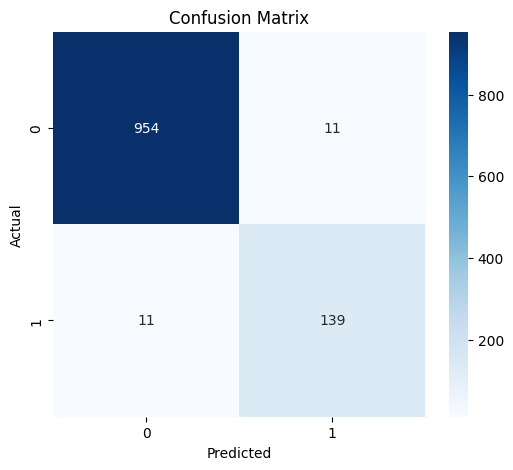

Confusion matrix plot generated successfully.


In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

# Add labels and title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Display the plot
plt.show()

print("Confusion matrix plot generated successfully.")

## Summary:

### Data Analysis Key Findings
*   Text data was successfully preprocessed, including cleaning, tokenization, stop word removal, and transformed into a TF-IDF matrix with 5,572 documents and 5,000 features.
*   The dataset was split into training (80%) and testing (20%) sets, with 4,457 samples for training and 1,115 samples for testing. The categorical target variable ('class') was numerically encoded.
*   A Multinomial Naïve Bayes classifier was successfully trained on the preprocessed training data.
*   The trained model achieved an accuracy of 0.9677 on the test set.
*   The precision for identifying spam messages was 0.9914, indicating that very few legitimate messages were incorrectly flagged as spam (only 1 false positive).
*   The recall for detecting spam messages was 0.7667, meaning that 76.67% of all actual spam messages were correctly identified.
*   The confusion matrix revealed:
    *   115 True Positives (correctly identified spam).
    *   964 True Negatives (correctly identified legitimate messages).
    *   1 False Positive (legitimate message incorrectly identified as spam).
    *   35 False Negatives (spam messages incorrectly identified as legitimate).

### Insights or Next Steps
*   The Naïve Bayes model exhibits high precision in spam detection, which is critical for user experience to minimize false alarms on legitimate emails.
*   To further enhance the model, focus should be placed on improving the recall rate by investigating the characteristics of the 35 false negative spam messages. This could involve exploring additional text features, different vectorization techniques, or alternative classification algorithms.
